In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
from data_science.plots import plot_confusion_matrix, plot_cumulative_explained_variance, plot_pca_scatter
from data_science.styles import apply_luna_style


In [4]:
apply_luna_style()

## Data

In [5]:
data = pd.read_csv(
    "./../data/wheat-seeds.csv",
    names=[
        "area",
        "perimeter",
        "compactness",
        "length of kernel",
        "width of kernel",
        "asymmetry coefficient",
        "length of groove",
        "type",
    ],
    header=None,
)

In [6]:
label_map = {1: "Kama", 2: "Rosa", 3: "Canadian"}
data["type"] = data["type"].map(label_map)

## Basic Statistics


In [7]:
data.head()

,area,perimeter,compactness,length of kernel,width of kernel,asymmetry coefficient,length of groove,type
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Kama


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area                   210 non-null    float64
 1   perimeter              210 non-null    float64
 2   compactness            210 non-null    float64
 3   length of kernel       210 non-null    float64
 4   width of kernel        210 non-null    float64
 5   asymmetry coefficient  210 non-null    float64
 6   length of groove       210 non-null    float64
 7   type                   210 non-null    object 
dtypes: float64(7), object(1)
memory usage: 13.3+ KB


## Prepare Data


In [9]:
RANDOM_STATE = 42
np.random.default_rng(RANDOM_STATE)

Generator(PCG64) at 0x1129DB220

In [10]:
X = data.drop(columns=["type"])
y = data["type"]

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

## LogisticRegression

### Without PCA

In [13]:
lr_no_pca = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)
lr_no_pca.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
y_pred_no_pca = lr_no_pca.predict(X_test)

In [15]:
print("Logistic Regression without PCA Results:")
accuracy = accuracy_score(y_test, y_pred_no_pca)
print(f"Accuracy: {accuracy * 100:.2f}%")
precision = precision_score(y_test, y_pred_no_pca, average="weighted")
print(f"Precision: {precision * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_no_pca))

Logistic Regression without PCA Results:
Accuracy: 90.48%
Precision: 90.48%

Classification Report:
              precision    recall  f1-score   support

    Canadian       0.88      0.88      0.88        17
        Kama       0.82      0.82      0.82        11
        Rosa       1.00      1.00      1.00        14

    accuracy                           0.90        42
   macro avg       0.90      0.90      0.90        42
weighted avg       0.90      0.90      0.90        42



In [16]:
cm = confusion_matrix(y_test, y_pred_no_pca)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[15  2  0]
 [ 2  9  0]
 [ 0  0 14]]


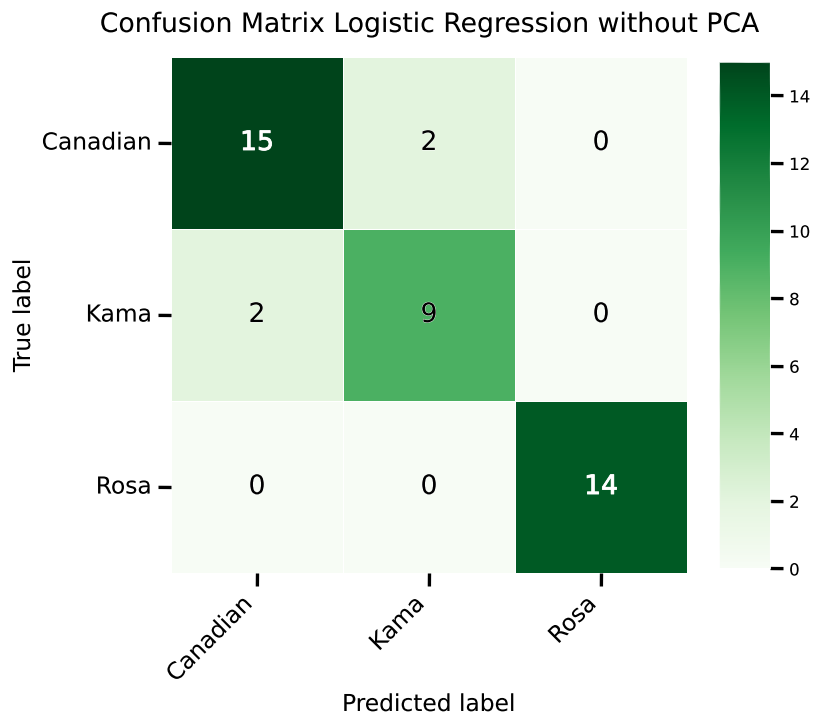

In [17]:
cm = confusion_matrix(y_test, y_pred_no_pca)
cm_classes = np.unique(np.r_[y_test, y_pred_no_pca])
plot_confusion_matrix(
    cm,
    cm_classes,
    title="Confusion Matrix Logistic Regression without PCA"
)

### With PCA (variance threshold = 0.95)

In [18]:
pca_95 = PCA(
    n_components=0.95,
    svd_solver="full",
    random_state=RANDOM_STATE,
)

In [19]:
X_pca_95 = pca_95.fit_transform(X_scaled)
X_pca_95.shape

(210, 3)

In [20]:
pca_95.explained_variance_ratio_

array([0.71874303, 0.17108184, 0.09685763])

In [21]:
pca_95.explained_variance_ratio_.sum()

np.float64(0.9866824959320446)

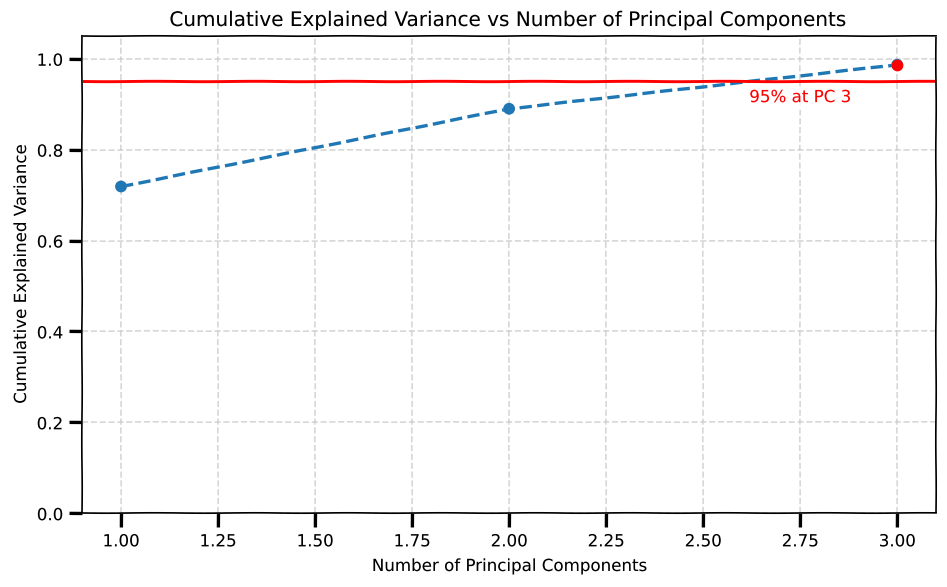

In [22]:
plot_cumulative_explained_variance(pca_95, threshold=0.95)

In [23]:
X_train_pca_95, X_test_pca_95, y_train, y_test = train_test_split(
    X_pca_95,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

In [24]:
model_pca_95 = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)
model_pca_95.fit(X_train_pca_95, y_train)
model_pca_95.score(X_test_pca_95, y_test)

0.8809523809523809

In [25]:
y_pred_pca_95 = model_pca_95.predict(X_test_pca_95)

In [26]:
print("Logistic Regression without PCA Results:")
accuracy = accuracy_score(y_test, y_pred_pca_95)
print(f"Accuracy: {accuracy * 100:.2f}%")
precision = precision_score(y_test, y_pred_pca_95, average="weighted")
print(f"Precision: {precision * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca_95))

Logistic Regression without PCA Results:
Accuracy: 88.10%
Precision: 88.39%

Classification Report:
              precision    recall  f1-score   support

    Canadian       0.88      0.82      0.85        17
        Kama       0.75      0.82      0.78        11
        Rosa       1.00      1.00      1.00        14

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42



In [27]:
cm = confusion_matrix(y_test, y_pred_pca_95)
print("Confusion Matrix for PCA with 95% Variance:")
print(cm)

Confusion Matrix for PCA with 95% Variance:
[[14  3  0]
 [ 2  9  0]
 [ 0  0 14]]


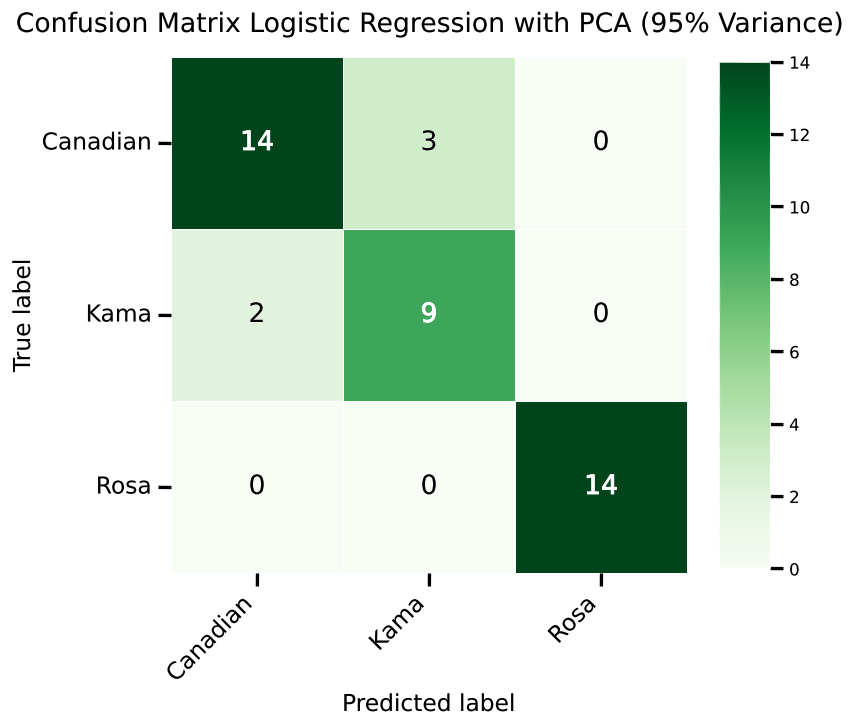

In [28]:
cm = confusion_matrix(y_test, y_pred_pca_95)
cm_classes = np.unique(np.r_[y_test, y_pred_pca_95])
plot_confusion_matrix(
    cm,
    cm_classes,
    title="Confusion Matrix Logistic Regression with PCA (95% Variance)"
)

### With PCA (2 components)

In [29]:
pca_2d = PCA(
    n_components=2,
    svd_solver="full",
    random_state=RANDOM_STATE,
)

In [30]:
X_pca_2d = pca_2d.fit_transform(X_scaled)
X_pca_2d.shape

(210, 2)

In [31]:
pca_2d.explained_variance_ratio_

array([0.71874303, 0.17108184])

In [32]:
pca_2d.explained_variance_ratio_.sum()

np.float64(0.8898248618491238)

In [33]:
X_train_pca_2d, X_test_pca_2d, y_train, y_test = train_test_split(
    X_pca_2d,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

In [34]:
model_pca_2d = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)
model_pca_2d.fit(X_train_pca_2d, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
y_pred_pca_2d = model_pca_2d.predict(X_test_pca_2d)

In [36]:
print("Logistic Regression without PCA Results:")
accuracy = accuracy_score(y_test, y_pred_pca_2d)
print(f"Accuracy: {accuracy * 100:.2f}%")
precision = precision_score(y_test, y_pred_pca_2d, average="weighted")
print(f"Precision: {precision * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca_2d))

Logistic Regression without PCA Results:
Accuracy: 88.10%
Precision: 88.39%

Classification Report:
              precision    recall  f1-score   support

    Canadian       0.88      0.82      0.85        17
        Kama       0.75      0.82      0.78        11
        Rosa       1.00      1.00      1.00        14

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42



In [37]:
cm = confusion_matrix(y_test, y_pred_pca_2d)
print("Confusion Matrix for PCA with 2 Components:")
print(cm)

Confusion Matrix for PCA with 2 Components:
[[14  3  0]
 [ 2  9  0]
 [ 0  0 14]]


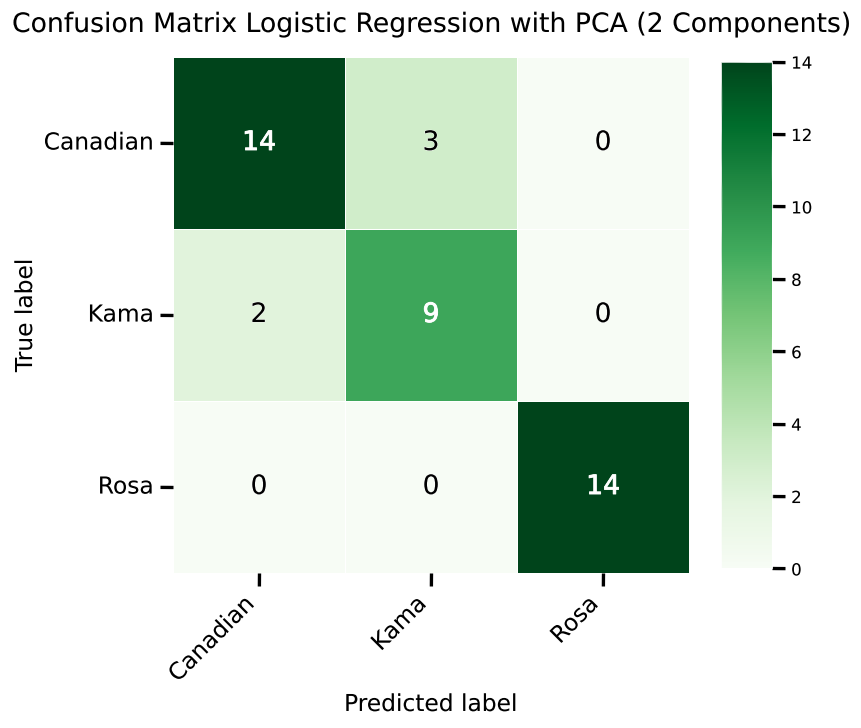

In [38]:
cm = confusion_matrix(y_test, y_pred_pca_2d)
cm_classes = np.unique(np.r_[y_test, y_pred_pca_2d])
plot_confusion_matrix(
    cm,
    cm_classes,
    title="Confusion Matrix Logistic Regression with PCA (2 Components)"
)

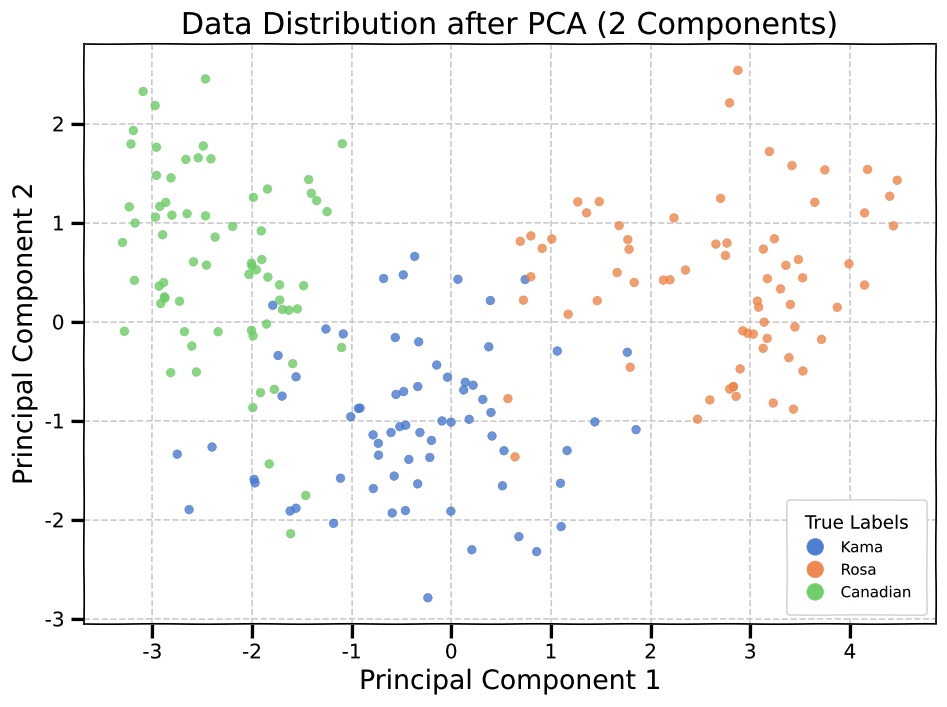

In [39]:
plot_pca_scatter(
    X_pca_2d,
    y,
    figsize=(8, 6),
    palette='muted',
    title="Data Distribution after PCA (2 Components)",
)